In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob, os, sparse

import bokeh.io
import bokeh.plotting
import bokeh.models
bokeh.io.output_notebook()

import seaborn as sns
import scipy.stats as st

import sklearn.model_selection
from sklearn.preprocessing import binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc, accuracy_score, balanced_accuracy_score, average_precision_score, confusion_matrix

import statsmodels as sm
import statsmodels.graphics.gofplots
plt.rcParams['figure.dpi'] = 150

from Bio import SeqIO
import warnings
warnings.filterwarnings("ignore")
from tensorflow.keras.models import load_model
from cnn_utils import *

results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/criticalConcentrations_updated.csv")
results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_resistance_variants_all.csv")

df_moxi = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/data_for_model.csv")
df_rif = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/data_for_model.csv")

Loading BokehJS ...

In [2]:
# history = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/20221219_moxi_gyrBA_lineage/history.csv")
# history["Epoch"] = history.index + 1
# patience_epochs = 25
# len(history)

# fig, ax = plt.subplots()
# sns.lineplot(x="Epoch", y="train_loss", data=history, label="train_loss", ax=ax)
# sns.lineplot(x="Epoch", y="val_loss", data=history, label="val_loss", ax=ax)

# ax.axvline(x=len(history)-patience_epochs, color="black", linestyle='--', linewidth=1)
# sns.despine()

# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title(f"Trained model for {len(history)-patience_epochs} epochs")
# plt.show()

## Input Data

Check what the original data looks like -- all of it, and the training and testing sets. 

In [5]:
def plot_init_data(pkl_path, drug):
    
    df = pd.read_pickle(pkl_path)
    
    train = np.log(df.loc[df.category == "original_train_set"][drug + "_midpoint"].values)
    test = np.log(df.loc[df.category == "original_test_set"][drug + "_midpoint"].values)

    p_train = iqplot.ecdf(train, title="Train Set", x_axis_label="Log MIC")
    p_test = iqplot.ecdf(test, title="Test Set", x_axis_label="Log MIC")

    bokeh.io.show(bokeh.layouts.row(p_train, p_test))
    
    # fig_output = pkl_path.split("/")[-1]
    # if not os.path.isdir(os.path.join("Figures", fig_output)):
    #     os.mkdir(os.path.join("Figures", fig_output))
    
    fig, ax = plt.subplots(figsize=(6, 4))
    plt.hist(np.log(df[drug + "_midpoint"].values))
    plt.title(f"{len(df)} Samples")
    plt.xlabel("Log MIC", fontsize=12)
    #plt.savefig(os.path.join("Figures", fig_output, "hist.png"))
    plt.show()

In [5]:
def compare_distributions(pkl_path, drug):
    
    df = pd.read_pickle(pkl_path)
    
    train = np.log(df.loc[df.category == "original_train_set"][drug + "_midpoint"].values)
    test = np.log(df.loc[df.category == "original_test_set"][drug + "_midpoint"].values)
    
    # fig_output = pkl_path.split("/")[-1]
    # if not os.path.isdir(os.path.join("Figures", fig_output)):
    #     os.mkdir(os.path.join("Figures", fig_output))

    sm.graphics.gofplots.qqplot_2samples(train, test, xlabel="Train Set", ylabel="Test Set", line="45")
    plt.title(f"QQ Plot of {len(df)} Samples")
    #plt.savefig(os.path.join("Figures", fig_output, "qqplot.png"))
    sns.despine()
    plt.show()
    
    print(st.ks_2samp(train, test))

# Cross-Validation Evaluation

Plot validation loss for all folds and then their average. 

In [51]:
def plot_cv_histories(path, plot_title="Validation Loss", binary=False):
        
    if binary:
        histories_df = pd.read_csv(os.path.join(path, "history_replicates_binary.csv"))
    else:
        histories_df = pd.read_csv(os.path.join(path, "history_replicates.csv"))

    fig, ax = plt.subplots(figsize=(10, 4))

    for i in range(histories_df.shape[1]):
        plt.plot(histories_df.index + 1, histories_df[f"rep_{i+1}"], color="lightgray")

    plt.plot(histories_df.index + 1, histories_df.mean(axis=1), color="red", linewidth=1.5)

    plt.xlabel("Epoch", fontsize=12)
    plot_title = plot_title + " for " + os.path.basename(path)
    plt.title(plot_title, fontsize=14)
    sns.despine()
    
    #plt.savefig(os.path.join(path, "Figures", "cv_histories.png"))
    plt.show()

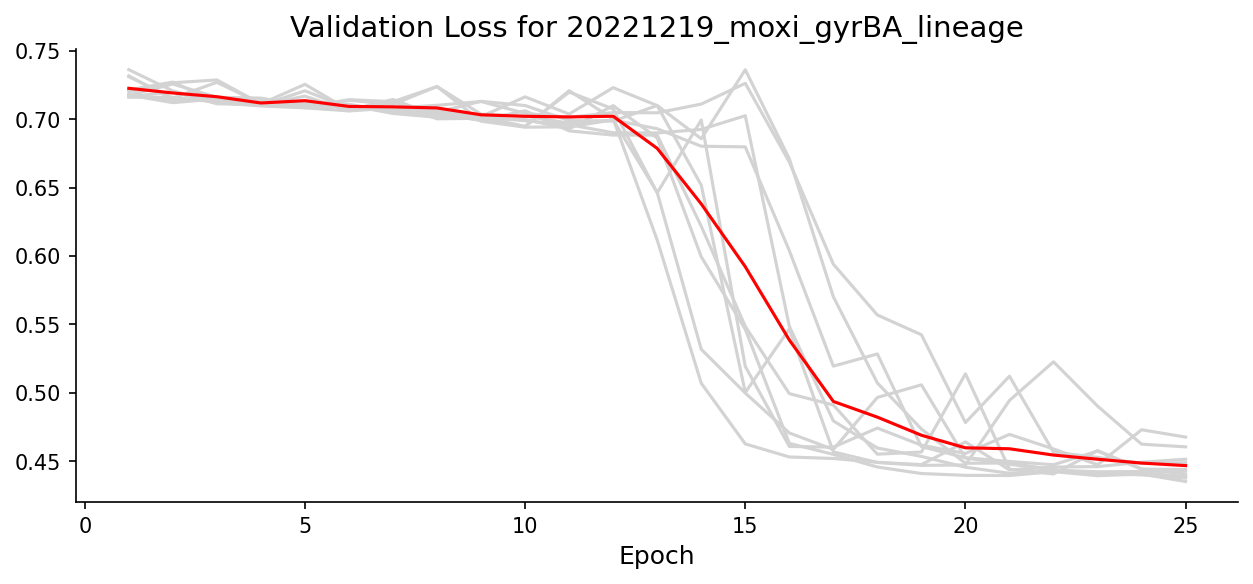

In [52]:
plot_cv_histories(os.path.join(results_path, "20221219_moxi_gyrBA_lineage"), binary=False)

# Analyze quantitative CNN

In [6]:
def test_for_independence(x1, x2, var, alt="two-sided", paired=False):
    
    if paired:
        return st.ttest_rel(x1.query("CV>0")[var], x2.query("CV>0")[var], alternative=alt)[1]
    else:
        return st.ttest_ind(x1.query("CV>0")[var], x2.query("CV>0")[var], alternative=alt, equal_var=False)[1]
        

def binary_model_analysis(path, drug, cc, num_loci, lineage=0, bs=True, plot=True):
    
    history = pd.read_csv(os.path.join(path, "binary_history.csv"))
    pred = pd.read_csv(os.path.join(path, "binary_test_predictions.csv"))

    stop_epoch = history.loc[history.val_loss == np.min(history.val_loss)].index.values[0] + 1
    print(f"{len(pred)} points in validation set")
    print(f"Trained CNN for {stop_epoch} epochs")
    
    if plot:
        fig, ax = plt.subplots(figsize=(4, 2))

        plt.plot(history.index+1, history["val_loss"], label="Loss")
        plt.title("Validation Loss", fontsize=14)
        #plt.xlim(0, stop_epoch)

        sns.despine()
        plt.xlabel("Epoch", fontsize=10)
    
    summary_df = pd.DataFrame({"Drug": drug,
                               "Model": "CNN",
                               "Num_Loci": num_loci,
                              }, index=[0])
    
    summary_df["Num_Loci"] = "Binary"
    summary_df["CV"] = 0
    summary_df["Lineage"] = lineage
    summary_metrics_df = compute_binary_metrics(pred.y_pred_label, pred.y_test, cc, binarize=False)
    summary_df = pd.concat([summary_df, summary_metrics_df], axis=1)
    
    if bs:
        cv_results = pd.read_csv(os.path.join(path, "binary_val_results.csv"))
        cv_results["CV"] = np.arange(len(cv_results))+1
        cv_results["Num_Loci"] = "Binary"
        cv_results["Lineage"] = lineage
        return pd.concat([summary_df, cv_results])
    else:
        return summary_df
    

def quant_model_analysis(path, drug, cc, df_phenos, num_loci, lineage=0, bs=True, plot=True):
    
    history = pd.read_csv(os.path.join(path, "history.csv"))
    pred_df = pd.read_csv(os.path.join(path, "test_predictions.csv"))
    
    print(f"{len(pred_df)} points in validation set")
    print(f"Trained CNN for {len(history)-25} epochs")
    
    if plot:
        fig, ax1 = plt.subplots(1, 1, figsize=(5, 2))

        ax1.plot(history.index+1, history["val_loss"], label="Loss")
        ax1.set_title("Validation Loss", fontsize=14)
        ax1.set_xlabel("Epoch", fontsize=10)
        sns.despine()

        fig, ax2 = plt.subplots(1, 1, figsize=(5, 4.5))
        
        values = np.vstack([pred_df["y_pred"], pred_df["y_test"]])
        kernel = st.gaussian_kde(values)(values)

        sns.scatterplot(
            data=pred_df,
            x="y_pred",
            y="y_test",
            c=kernel,
            cmap="Blues",
            linewidth=0.25,
            edgecolor="lightgray",
            ax=ax2
        )

        max_val = np.max([pred_df.y_pred, pred_df.y_test]) * 1.1
        min_val = np.min([pred_df.y_pred, pred_df.y_test]) * 1.1

        ax2.set_xlabel("Predicted log(MIC)")
        ax2.set_ylabel("Actual log(MIC)")
        ax2.set_xlim(min_val, max_val)
        ax2.set_ylim(min_val, max_val)

        sns.despine()
        plt.show()
        
    binned_mae, within_1bin = bounded_mae_standalone(pred_df, "y_pred", "y_test", "lower", "upper")
    mae = np.mean(np.abs(pred_df.y_pred - pred_df.y_test))
    # rmse = np.mean((pred_df.y_pred - pred_df.y_test)**2)
    
    summary_df = pd.DataFrame({"Drug": drug,
                               "Model": "CNN",
                               "Num_Loci": num_loci,
                               "Binned_MAE": binned_mae,
                               "MAE": mae,
                               "Within_1bin": within_1bin,
                               # "RMSE": rmse,
                               "Pearson": st.pearsonr(pred_df.y_pred, pred_df.y_test)[0],
                               "Lineage": lineage,
                               "CV": 0
                              }, index=[0])
    
    binary_metrics = compute_binary_metrics(pred_df.y_test, pred_df.y_pred, cc, binarize=True)
    summary_df = pd.concat([summary_df, binary_metrics], axis=1)
    
    if bs:
        cv_results = pd.read_csv(os.path.join(path, "val_results.csv"))
        cv_results["CV"] = np.arange(len(cv_results))+1
        cv_results["Num_Loci"] = num_loci
        cv_results["Lineage"] = lineage
        return pd.concat([summary_df, cv_results])
    else:
        return summary_df
    
    
def analyze_linReg_models(path, lineage=0, num_loci=1, binary=False):
    
    if binary:
        prefix = "binary_"
    else:
        prefix = ""
    
    model_res = pd.read_csv(os.path.join(results_path, path, "ridge", f"{prefix}ridge_results.csv"))

    if binary:
        metrics = ["Sensitivity", "Specificity", "AUC", "AUC_PR"]
        model_res["Num_Loci"] = "Binary"
    else:
        metrics = ["MAE", "RMSE", "Pearson R", "Sensitivity", "Specificity", "AUC", "AUC_PR"]
        model_res["Num_Loci"] = num_loci
        
#     for metric in metrics:
#         print(f"{metric}: {np.round(model_res.query('CV==0')[metric].values[0], 4)}, CI: {np.round(np.percentile(model_res.query('CV>0')[metric], q=[2.5, 97.5]), 4)}")
        
    model_res["Lineage"] = lineage
    return model_res

1460 points in validation set
Trained CNN for 25 epochs


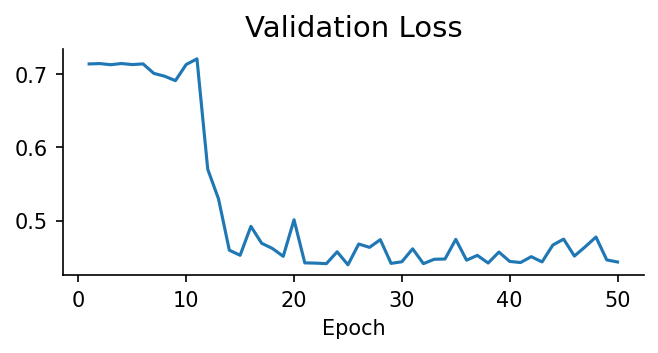

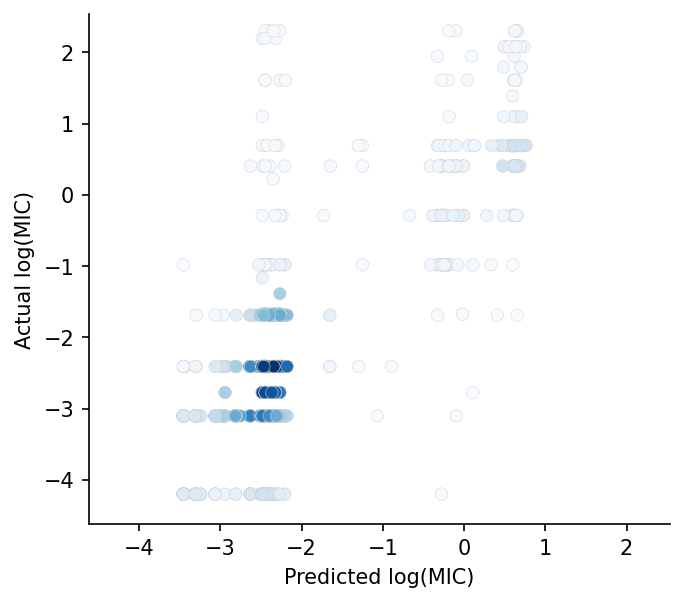

In [7]:
moxi_gyrBA_lineage = quant_model_analysis("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/20221219_moxi_gyrBA_lineage", "MOXI", 0.5, df_moxi, 1, lineage=1, bs=True)

1871 points in validation set
Trained CNN for 152 epochs


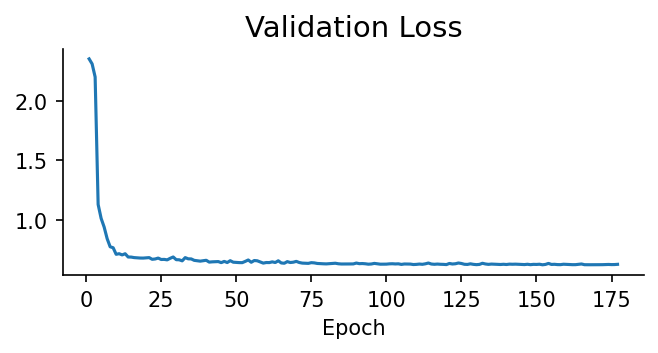

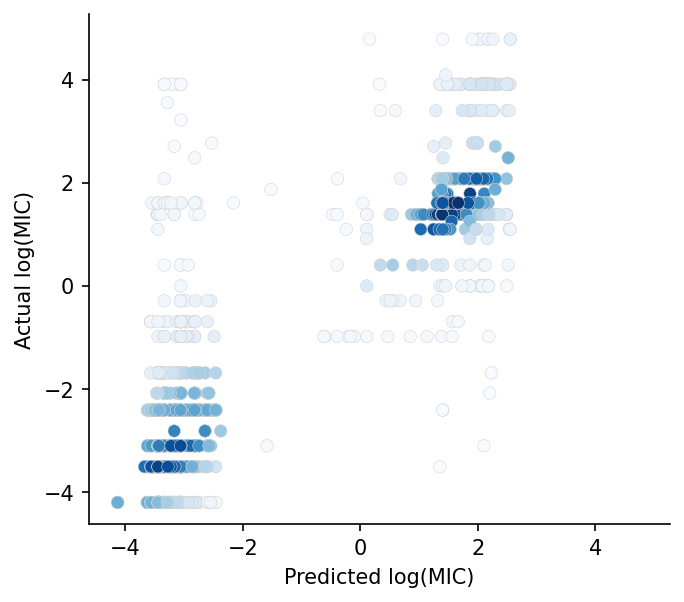

In [8]:
rif_rpoBC_lineage = quant_model_analysis("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/20221219_rif_rpoBC_lineage", "RIF", 0.5, df_rif, 1, lineage=1, bs=False)



In [11]:
moxi_gyrBA_lineage

,Drug,Model,Num_Loci,Binned_MAE,MAE,Within_1bin,Pearson,Lineage,CV,Sensitivity,Specificity,AUC,AUC_PR,Accuracy,Balanced_Acc
0,MOXI,CNN,1,0.516848,0.590106,0.871918,0.798095,1,0,0.864979,0.977923,0.921451,0.786231,0.959589,0.921451
0,MOXI,CNN,1,0.510044,0.587438,NaN,0.800035,1,1,0.864979,0.977923,0.921451,0.786231,0.959589,0.921451
1,MOXI,CNN,1,0.513665,0.606802,NaN,0.797509,1,2,0.864979,0.977923,0.921451,0.786231,0.959589,0.921451
2,MOXI,CNN,1,0.518896,0.594668,NaN,0.798179,1,3,0.860759,0.977923,0.919341,0.782754,0.958904,0.919341
3,MOXI,CNN,1,0.516456,0.591958,NaN,0.796501,1,4,0.860759,0.977923,0.919341,0.782754,0.958904,0.919341
4,MOXI,CNN,1,0.533153,0.607367,NaN,0.797880,1,5,0.864979,0.977923,0.921451,0.786231,0.959589,0.921451
5,MOXI,CNN,1,0.523159,0.601110,NaN,0.797810,1,6,0.864979,0.977923,0.921451,0.786231,0.959589,0.921451
6,MOXI,CNN,1,0.522323,0.593802,NaN,0.794631,1,7,0.843882,0.977923,0.910902,0.768851,0.956164,0.910902
7,MOXI,CNN,1,0.521543,0.590192,NaN,0.795781,1,8,0.864979,0.977923,0.921451,0.786231,0.959589,0.921451
8,MOXI,CNN,1,0.525506,0.599917,NaN,0.793341,1,9,0.839662,0.977923,0.908793,0.765376,0.955479,0.908793


In [34]:
for var in ["Binned_MAE", "MAE", "RMSE", "Pearson", "Within_1Bin", "Sensitivity", "Specificity", "AUC", "Accuracy", "Balanced_Acc"]:
    
    pval = test_for_independence(cryptic_model, cryptic_model_lineage, var, alt="two-sided", paired=False)
    if pval < 0.05:
        print(var, pval)

Binned_MAE 3.186388132937564e-06
MAE 1.0110945310135145e-14
RMSE 4.9887662095478676e-11
Pearson 1.1222340603908043e-13
Within_1Bin 0.012002124599337352
Sensitivity 0.0004631040601832628
Specificity 9.275529564583422e-08
AUC 0.002529164734646995
Balanced_Acc 0.002529164734647028


In [35]:
for var in ["Binned_MAE", "MAE", "Pearson", "Within_1Bin"]:
    
    print(var)
    print(np.percentile(cryptic_model.query("CV > 0")[var], q=[2.5, 97.5]))
    print(np.percentile(cryptic_model_lineage.query("CV > 0")[var], q=[2.5, 97.5]))
    print("\n")

Binned_MAE
[0.46973074 0.53899257]
[0.41180872 0.45707752]


MAE
[0.59371295 0.61127548]
[0.54304552 0.55547658]


Pearson
[0.83224378 0.84056042]
[0.85851212 0.86611847]


Within_1Bin
[0.7377829  0.84798826]
[0.82231769 0.88581308]




# Rifampicin

In [6]:
rif_rpoBC_mse = quant_model_analysis(os.path.join(results_path, "20221031_rif_rpoBC_mse"), "RIF", 0.5, df_rif, 1, lineage=0, bs=True, plot=False)
rif_rpoBC_mae = quant_model_analysis(os.path.join(results_path, "20220904_rif_rpoBC"), "RIF", 0.5, df_rif, 1, lineage=0, bs=True, plot=False)

1897 points in validation set
Trained CNN for 169 epochs
1897 points in validation set
Trained CNN for 197 epochs


In [15]:
for var in ["Pearson R", "Sensitivity", "Specificity", "AUC"]:
    print(f"\n{var}")
    print(test_for_independence(rif_rpoBC_mae.query("CV>0")[var], rif_rpoBC_mse.query("CV>0")[var], paired=True))
    # print(test_for_independence(rif_rpoBC_mae.query("CV>0")[var], rif_rpoBC_mse.query("CV>0")[var], paired=False))


Pearson R
0.0007700954271092553

Sensitivity
0.24198153056801205

Specificity
0.373900966300059

AUC
0.3622463873286514


In [19]:
mse_pred = pd.read_csv(os.path.join(results_path, "20221031_rif_rpoBC_mse", "test_predictions.csv"))
mae_pred = pd.read_csv(os.path.join(results_path, "20220904_rif_rpoBC", "test_predictions.csv"))

mae_pred["error"] = mae_pred["y_pred"] - mae_pred["y_test"]
mse_pred["error"] = mse_pred["y_pred"] - mse_pred["y_test"]

mse_pred["y_pred_binary"] = (mse_pred["y_pred"] > 0.5).astype(int)
mse_pred["y_test_binary"] = (mse_pred["y_test"] > 0.5).astype(int)
mae_pred["y_pred_binary"] = (mae_pred["y_pred"] > 0.5).astype(int)
mae_pred["y_test_binary"] = (mae_pred["y_test"] > 0.5).astype(int)

In [26]:
print(sklearn.metrics.accuracy_score(mse_pred["y_test_binary"], mse_pred["y_pred_binary"]))
print(sklearn.metrics.accuracy_score(mae_pred["y_test_binary"], mae_pred["y_pred_binary"]))

0.9573010015814444
0.9599367422245652


In [27]:
print(sklearn.metrics.balanced_accuracy_score(mse_pred["y_test_binary"], mse_pred["y_pred_binary"]))
print(sklearn.metrics.balanced_accuracy_score(mae_pred["y_test_binary"], mae_pred["y_pred_binary"]))

0.9578614477408887
0.9595127204591962


1442 points in validation set


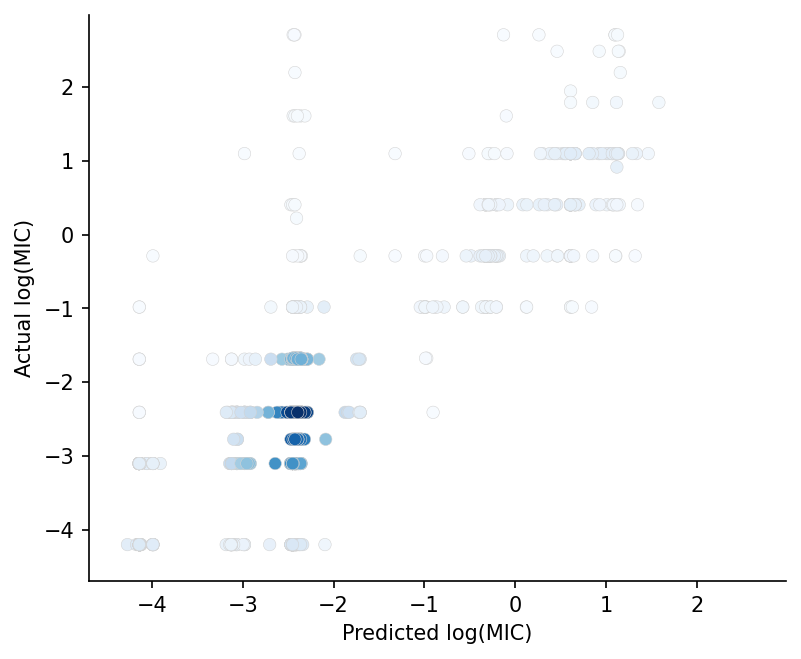

In [99]:
pred = pd.read_csv(os.path.join(results_path, "20221102_moxi_gyrBA_lineage", "test_predictions.csv"))

print(f"{len(pred)} points in validation set")

fig, ax = plt.subplots(1, 1, figsize=(6, 5))

# ax[0].scatter(pred.y_pred, pred.y_test, alpha=0.7, s=15
#            # edgecolors="black"
#            )

values = np.vstack([pred["y_pred"], pred["y_test"]])
kernel = st.gaussian_kde(values)(values)

sns.scatterplot(
    data=pred,
    x="y_pred",
    y="y_test",
    c=kernel,
    cmap="Blues",
    linewidth=0.25,
    edgecolor="lightgray",
    ax=ax
)
    
# sns.kdeplot(
#     data=pred, x="y_pred", y="y_test",
#     c=kernel,
#     cbar=False,
#     thresh=0, levels=100,
#     fill=True, cmap="viridis", ax=ax[1]
# )

max_val = np.max([pred.y_pred, pred.y_test]) * 1.1
min_val = np.min([pred.y_pred, pred.y_test]) * 1.1

ax.set_xlabel("Predicted log(MIC)")
ax.set_ylabel("Actual log(MIC)")

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

sns.despine()
# plt.savefig("pred.png", dpi=300)
plt.show()

In [83]:
rif_rpoBC = quant_model_analysis(os.path.join(results_path, "20220904_rif_rpoBC"), "RIF", 0.5, df_rif, 1, lineage=0, bs=True, plot=False)

rif_rpoBC_binary = binary_model_analysis(os.path.join(results_path, "20220904_rif_rpoBC"), "RIF", 0.5, 1, lineage=0, bs=True, plot=False)
rif_rpoBC_binary["Num_Loci"] = "Binary"

# pd.concat([rif_rpoBC, rif_rpoBC_binary]).to_csv("rif_cnn_summaries.csv", index=False)

1897 points in validation set
Trained CNN for 197 epochs
1897 points in validation set
Trained CNN for 221 epochs


In [84]:
rif_rpoBC_lineage = quant_model_analysis(os.path.join(results_path, "20221006_rif_rpoBC"), "RIF", 0.5, df_rif, 1, lineage=1, bs=True, plot=False)
rif_rpoABC = quant_model_analysis(os.path.join(results_path, "20221021_rif_rpoABC"), "RIF", 0.5, df_rif, 2, lineage=0, bs=True, plot=False)
rif_rpoABC_Rv2752c = quant_model_analysis(os.path.join(results_path, "20221025_rif_rpoABC_Rv2752c"), "RIF", 0.5, df_rif, 3, lineage=0, bs=True, plot=False)

1897 points in validation set
Trained CNN for 202 epochs
1897 points in validation set
Trained CNN for 124 epochs
1897 points in validation set
Trained CNN for 138 epochs


In [85]:
rif_rpoBC_linReg = analyze_linReg_models("20220904_rif_rpoBC", lineage=0, num_loci=1, binary=False)
rif_rpoBC_lineage_linReg = analyze_linReg_models("20221006_rif_rpoBC", lineage=1, num_loci=1, binary=False)
rif_rpoABC_linReg = analyze_linReg_models("20220904_rif_rpoBC", lineage=0, num_loci=2, binary=False)
rif_rpoABC_Rv2752c_linReg = analyze_linReg_models("20221006_rif_rpoBC", lineage=0, num_loci=3, binary=False)

In [86]:
rif_all = pd.concat([rif_rpoBC_linReg, rif_rpoBC, rif_rpoBC_lineage_linReg, rif_rpoBC_lineage, rif_rpoABC, rif_rpoABC_linReg, rif_rpoABC_Rv2752c, rif_rpoABC_Rv2752c_linReg])
print(rif_all.shape)
print(rif_all.drop_duplicates(["Model", "Num_Loci", "Lineage", "CV"]).shape)

rif_all["Group"] = [1]*12 + [2]*12 + [3]*12 + [4]*12

(48, 17)
(48, 17)


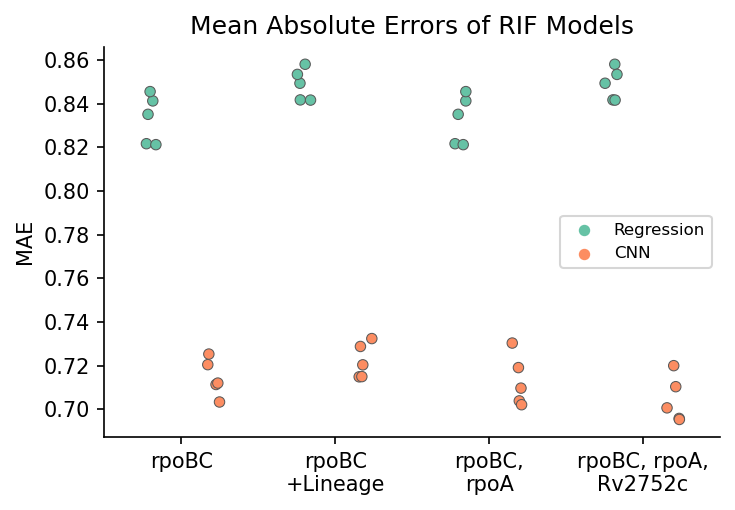

In [38]:
plot_quant_models(rif_all, "Group", "MAE", "Mean Absolute Errors of RIF Models", save_title="../Figures/rif_4Model_comparison.png")

In [9]:
def plot_quant_models(df, x_var, quant_var, title, tick_labels, plot_width, save_title=None):

    if x_var == "Model":
        quant_plot = df.query("CV > 0'").melt(id_vars=["Model"], value_vars=quant_var)
    else:
        quant_plot = df.query("CV > 0").melt(id_vars=["Model", x_var], value_vars=quant_var)
    
    quant_plot["Model"] = quant_plot["Model"].replace("LinReg", "Regression")
    quant_plot["Model"] = quant_plot["Model"].replace("LogReg", "Regression")
        
    palette = sns.color_palette("Set2")
    palette = palette.as_hex()
    color_dict = dict(zip(quant_plot["Model"].unique(), palette[:len(quant_plot["Model"].unique())]))

    fig, ax = plt.subplots(1, 1, figsize=(plot_width, 3.5))
    sns.stripplot(x=x_var, y="value",
                    hue="Model", 
                  dodge=True,
                    data = quant_plot,
                    palette=color_dict,
                  #order=["1", "12"],
                  hue_order=["Regression", "CNN"],
                  linewidth=0.5,
                  ax=ax
                     )



    #plt.ylim(0.5, 0.7)
    ax.get_legend().remove()
    
    legend = plt.legend(loc="upper right", fancybox=True, fontsize=8)
    legend.legendHandles[0]._sizes = [20]
    legend.legendHandles[1]._sizes = [20]
    
    plt.title(title)
    plt.xlabel("")
    plt.ylabel(quant_var)
    plt.xticks(ticks=ax.get_xticks(), labels=tick_labels)
    
    sns.despine()
    plt.tight_layout()
    
    if save_title is None:
        plt.show()
    else:
        plt.savefig(save_title, dpi=300)

# Moxifloxacin

In [11]:
moxi_gyrBA = quant_model_analysis(os.path.join(results_path, "20220902_moxi_gyrBA"), "MOXI", 0.5, df_moxi, 1, lineage=0, bs=True, plot=False)
moxi_gyrBA_lineage = quant_model_analysis(os.path.join(results_path, "20221006_moxi_gyrBA"), "MOXI", 0.5, df_moxi, 1, lineage=1, bs=True, plot=False)

moxi_gyrBA_lineage = quant_model_analysis(os.path.join(results_path, "20221006_moxi_gyrBA"), "MOXI", 0.5, df_moxi, 1, lineage=1, bs=True, plot=False)
moxi_new_lineage = quant_model_analysis(os.path.join(results_path, "20221102_moxi_gyrBA_lineage"), "MOXI", 0.5, df_moxi, 1, lineage=2, bs=True, plot=False)

moxi_12Loci = quant_model_analysis(os.path.join(results_path, "20220907_moxi_12Loci"), "MOXI", 0.5, df_moxi, 12, lineage=0, bs=True, plot=False)
moxi_12Loci_lineage = quant_model_analysis(os.path.join(results_path, "20221009_moxi_12Loci"), "MOXI", 0.5, df_moxi, 12, lineage=1, bs=True, plot=False)

1442 points in validation set
Trained CNN for 456 epochs
1442 points in validation set
Trained CNN for 164 epochs
1442 points in validation set
Trained CNN for 164 epochs
1442 points in validation set
Trained CNN for 438 epochs
1442 points in validation set
Trained CNN for 612 epochs
1442 points in validation set
Trained CNN for 499 epochs


In [12]:
moxi_gyrBA_linReg = analyze_linReg_models("20220902_moxi_gyrBA", lineage=0, num_loci=1, binary=False)
moxi_gyrBA_binary_logReg = analyze_linReg_models("20220902_moxi_gyrBA", lineage=0, num_loci=1, binary=True)

moxi_gyrBA_lineage_linReg = analyze_linReg_models("20221006_moxi_gyrBA", lineage=1, num_loci=1, binary=False)
moxi_new_lineage_linReg = analyze_linReg_models("20221102_moxi_gyrBA_lineage", lineage=1, num_loci=2, binary=False)

moxi_12Loci_linReg = analyze_linReg_models("20220907_moxi_12Loci", lineage=0, num_loci=12, binary=False)
moxi_12Loci_lineage_linReg = analyze_linReg_models("20221009_moxi_12Loci", lineage=1, num_loci=12, binary=False)

In [13]:
moxi_all = pd.concat([#moxi_gyrBA_binary_logReg, moxi_gyrBA_binary, 
    moxi_gyrBA_linReg, moxi_gyrBA, 
    moxi_gyrBA_lineage_linReg, moxi_gyrBA_lineage, 
    moxi_new_lineage_linReg, moxi_new_lineage,
                      moxi_12Loci_linReg, moxi_12Loci, moxi_12Loci_lineage_linReg, 
                      moxi_12Loci_lineage,
    
                     ])
print(moxi_all.shape)
print(moxi_all.drop_duplicates(["Model", "Num_Loci", "Lineage", "CV"]).shape)

moxi_all["Group"] = [1]*12 + [2]*12 + [3]*12 + [4]*12 + [5]*12

(60, 21)
(60, 21)


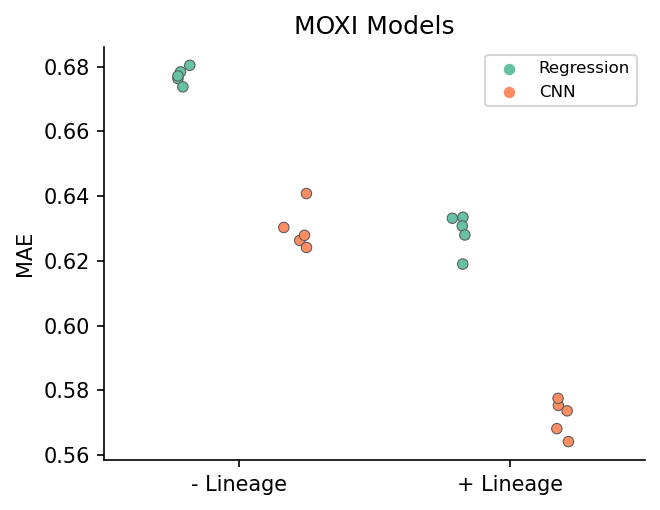

In [18]:
plot_quant_models(moxi_all.query("Group in [1, 3]"), "Group", "MAE", "MOXI Models", ["- Lineage", #"gyrBA +\nSNPs", 
                                                                                     "+ Lineage",
                                                                                     #"12 Loci", "12 Loci +\nSNPs"
                                                                                    ],
                                                                                     4.5, 
                  save_title="../Figures/moxi_lineage_comparison.png"
                 )

In [25]:
test_for_independence(moxi_gyrBA, moxi_new_lineage, "MAE", alt="two-sided", paired=False)

4.4368478996967894e-07


In [26]:
test_for_independence(moxi_gyrBA_linReg, moxi_new_lineage_linReg, "MAE", alt="two-sided", paired=False)

7.92706883903927e-06


In [27]:
test_for_independence(moxi_gyrBA, moxi_gyrBA_linReg, "MAE", alt="two-sided", paired=False)

1.830296233870727e-05


In [28]:
test_for_independence(moxi_gyrBA_lineage, moxi_gyrBA_lineage_linReg, "MAE", alt="two-sided", paired=False)

1.914300913538661e-05


In [55]:
test_for_independence(moxi_gyrBA_lineage, moxi_new_lineage, "MAE", alt="two-sided", paired=False)

0.14853183543782617


In [58]:
test_for_independence(moxi_gyrBA_lineage, moxi_12Loci, "MAE", alt="two-sided", paired=False)

0.14971989894488752


In [59]:
test_for_independence(moxi_gyrBA_lineage, moxi_12Loci_lineage, "MAE", alt="two-sided", paired=False)

0.13895658958063212


In [60]:
test_for_independence(moxi_new_lineage, moxi_12Loci, "MAE", alt="two-sided", paired=False)

0.010437299554860476


In [61]:
test_for_independence(moxi_new_lineage, moxi_12Loci_lineage, "MAE", alt="two-sided", paired=False)

0.014824065026568804


In [104]:
var = "MAE"
test_for_independence(moxi_gyrBA.query("CV>0")[var], moxi_gyrBA_linReg.query("CV>0")[var], paired=True)

0.00014074130293840253

In [105]:
var = "AUC"
test_for_independence(moxi_gyrBA_lineage.query("CV>0")[var], moxi_12Loci.query("CV>0")[var], paired=True)

0.20543330793794393

In [106]:
test_for_independence(moxi_gyrBA_lineage.query("CV>0")["MAE"], moxi_gyrBA.query("CV>0")["MAE"], paired=True)

7.083918104591547e-06

# Which Genes Contributed Most to Performance Gains?

In [25]:
locus_list = ['gyrBA', 'Rv0981_Rv0984', 
              'Rv2836c_Rv2837c', 
              'Rv3361c_Rv3365c', 'Rv0014c_Rv0015c', 'arfABC', 'phoPR', 'mbtK', 'Rv3561_Rv3565', 'stp', 
              'Rv0053_Rv0058', 'ligD_Rv0939'][1:]

In [26]:
dfs_lst = []
for locus in locus_list:
    df = quant_model_analysis(os.path.join(results_path, f"20220912_moxi_gyrBA_{locus}"), "MOXI", 0.5, df_moxi, 2, bs=True, plot=False)
    df["Gene"] = locus
    dfs_lst.append(df)
    
df_add_loci = pd.concat(dfs_lst)

1442 points in validation set
Trained CNN for 462 epochs
1442 points in validation set
Trained CNN for 462 epochs
1442 points in validation set
Trained CNN for 462 epochs
1442 points in validation set
Trained CNN for 462 epochs
1442 points in validation set
Trained CNN for 462 epochs
1442 points in validation set
Trained CNN for 462 epochs
1442 points in validation set
Trained CNN for 462 epochs
1442 points in validation set
Trained CNN for 462 epochs
1442 points in validation set
Trained CNN for 462 epochs
1442 points in validation set
Trained CNN for 462 epochs
1442 points in validation set
Trained CNN for 462 epochs


In [27]:
#moxi_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/isolate_variants.csv")

In [28]:
# # check the sequence quality for candidate loci
# genotype_input_directory = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas"
# locus_list = ['gyrBA', 'Rv3561_Rv3565', 'Rv0981_Rv0984', 'Rv3361c_Rv3365c'] 

# for locus in locus_list:
#     with open(os.path.join(genotype_input_directory, locus + ".sh"), "r") as file:
#         lines = file.readlines()
        
#         start, end = lines[-1].split("-")
#         start = int(start.split(" ")[-1])
#         end = int(end.split(" ")[0])
#         single_locus = moxi_isolate_variants.query("POS >= @start & POS <= @end")
#         print(f"{locus}:", single_locus.QC.value_counts(dropna=False)[1] / len(single_locus))

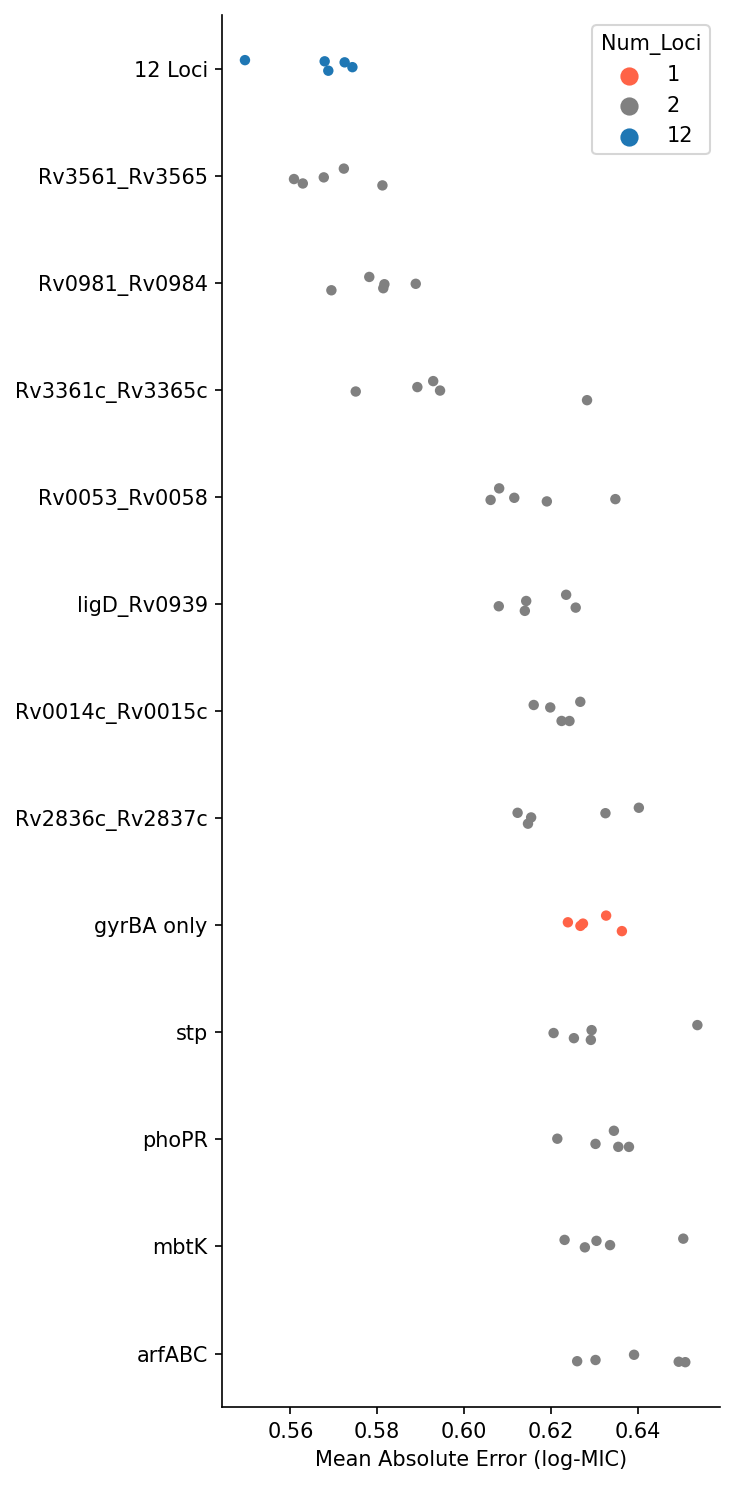

In [32]:
df_plot = pd.concat([df_add_loci.query("CV>0"), 
                     moxi_gyrBA.query("CV>0"), 
                     moxi_12Loci.query("CV>0")
                    ]).reset_index(drop=True)

df_plot.loc[df_plot["Num_Loci"] == 1, "Gene"] = "gyrBA only"
df_plot.loc[df_plot["Num_Loci"] == 12, "Gene"] = "12 Loci"
df_plot["Num_Loci"] = df_plot["Num_Loci"].astype(int)

# order by increasing mean
plot_order = df_plot.groupby("Gene")["MAE"].mean().sort_values().index.values

palette = {
    2: 'gray',
    12: '#1f77b4',
    1: 'tomato',
}

fig, ax = plt.subplots(1, 1, figsize=(5, 10))
sns.stripplot(data=df_plot, y="Gene", x="MAE", hue="Num_Loci", order=plot_order, palette=palette, dodge=False, ax=ax)
plt.xlabel("Mean Absolute Error (log-MIC)")
plt.ylabel("")
#plt.xticks(rotation=90)
sns.despine()
#plt.show()
plt.tight_layout()
plt.savefig("../Figures/moxi_12Loci_pairwise.png", dpi=300)

In [26]:
# df_plot = pd.concat([df_add_loci.query("CV==0"), 
#                      moxi_gyrBA.query("CV==0"), 
#                      moxi_12Loci.query("CV==0")
#                     ]).reset_index(drop=True)

# df_plot.loc[df_plot["Num_Loci"] == 1, "Gene"] = "gyrBA only"
# df_plot.loc[df_plot["Num_Loci"] == 12, "Gene"] = "12 Loci"
# df_plot["Num_Loci"] = df_plot["Num_Loci"].astype(int)

# # order by increasing mean
# plot_order = df_plot.groupby("Gene")["MAE"].mean().sort_values().index.values

# palette = {
#     2: 'gray',
#     12: '#1f77b4',
#     1: 'tomato',
# }

# fig, ax = plt.subplots(1, 1, figsize=(4, 10))
# sns.barplot(data=df_plot, y="Gene", x="MAE", hue="Num_Loci", order=plot_order, palette=palette, dodge=False, ax=ax)
# plt.xlabel("Mean Absolute Error (log-MIC)")
# plt.ylabel("")
# #plt.xticks(rotation=90)
# sns.despine()
# plt.show()

# Differences between single- and 12-Loci Models

## 1. Get predictions on full dataset, not just the testing dataset

In [43]:
def get_model_predictions(output_path, df_phenos):
    
    model = load_model(os.path.join(output_path, 'best_model.h5'))
    phenotype_file = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220902_data_clean.csv"
    drug = "MOXI"
    locus_list = ['gyrBA', 'Rv0981_Rv0984', 'Rv2836c_Rv2837c', 'Rv3361c_Rv3365c', 'Rv0014c_Rv0015c', 'arfABC', 'phoPR', 'mbtK', 'Rv3561_Rv3565', 'stp', 'Rv0053_Rv0058', 'ligD_Rv0939']
    BATCH_SIZE = 128
    binary_thresh = 0.05
    
    train_generator = MtbGeneDataset(
                        os.path.join(output_path, 'pkl_sparse_train.npz'),
                        phenotype_file,
                        drug,
                        locus_list,
                        train_or_test="original_train_set",
                        binary=False,
                        cc=binary_thresh,
                        data_idx=None,
                        batch_size=BATCH_SIZE,
                        shuffle=True
                        )

    val_generator = MtbGeneDataset(
                        os.path.join(output_path, 'pkl_sparse_test.npz'),
                        phenotype_file,
                        drug,
                        locus_list,
                        train_or_test="original_test_set",
                        binary=False,
                        cc=binary_thresh,
                        data_idx=None,
                        batch_size=BATCH_SIZE,
                        shuffle=False
                    )
    
    # get model predictions
    y_pred_train = model.predict(
        x=train_generator,
        workers=4,
        use_multiprocessing=True,
    )
    
    y_pred_val = model.predict(
        x=val_generator,
        workers=4,
        use_multiprocessing=True,
    )

    # get test values and IDs from the dataset class
    ids_train = np.array([])
    ids_val = np.array([])
    y_test_train = np.array([])
    y_test_val = np.array([])
    
    for i, _ in enumerate(train_generator):

        batch = train_generator.__getTestData__(i)

        ids_train = np.concatenate([ids_train, batch[0]])
        y_test_train = np.concatenate([y_test_train, batch[1]])

    for i, _ in enumerate(val_generator):

        batch = val_generator.__getTestData__(i)

        ids_val = np.concatenate([ids_val, batch[0]])
        y_test_val = np.concatenate([y_test_val, batch[1]])
        
    pred_df = pd.DataFrame({"Isolate": np.concatenate([ids_train, ids_val]), 
                            "y_pred": np.concatenate([np.squeeze(y_pred_train), np.squeeze(y_pred_val)]),
                            "y_test": np.concatenate([y_test_train, y_test_val]),
                            "category": ["original_train_set"]*len(ids_train) + ["original_test_set"]*len(ids_val)
                           })
    
    return pred_df.merge(df_phenos[["ROLLINGDB_ID", "category"]], left_on="Isolate", right_on="ROLLINGDB_ID")

In [44]:
gyrBA_pred = get_model_predictions(os.path.join(results_path, "20220902_moxi_gyrBA"), df_moxi)
multiLoci_pred = get_model_predictions(os.path.join(results_path, "20220907_moxi_12Loci"), df_moxi)

12 loci, longest locus: 4831, 5767 isolates
12 loci, longest locus: 4831, 1442 isolates
12/12 [==============================] - 39s 3s/step
12 loci, longest locus: 5822, 5767 isolates
12 loci, longest locus: 5822, 1442 isolates
12/12 [==============================] - 135s 9s/step


In [6]:
gyrBA_pred["y_binary_gyrBA_pred"] = (gyrBA_pred.y_pred > np.log(0.5)).astype(int)
gyrBA_pred["y_binary_test"] = (gyrBA_pred.y_test > np.log(0.5)).astype(int)

multiLoci_pred["y_binary_multiLoci_pred"] = (multiLoci_pred.y_pred > np.log(0.5)).astype(int)

gyrBA_pred.rename(columns={"y_pred": "y_gyrBA_pred"}, inplace=True)
multiLoci_pred.rename(columns={"y_pred": "y_multiLoci_pred"}, inplace=True)

pred_analysis = gyrBA_pred.merge(multiLoci_pred[["Isolate", "y_multiLoci_pred", "y_binary_multiLoci_pred"]], on="Isolate")

# absolute error
pred_analysis["error_multiLoci"] = pred_analysis["y_multiLoci_pred"] - pred_analysis["y_test"]
pred_analysis["error_gyrBA"] = pred_analysis["y_gyrBA_pred"] - pred_analysis["y_test"]

In [58]:
pred_analysis.query("category == 'original_test_set' & (error_multiLoci > 1 | error_multiLoci < -1 | error_gyrBA > 1 | error_gyrBA < -1)")

,Isolate,y_gyrBA_pred,y_test,ROLLINGDB_ID,category,y_binary_gyrBA_pred,y_binary_test,y_multiLoci_pred,y_binary_multiLoci_pred,error_multiLoci,error_gyrBA
5785,ERR4810964,-0.835585,-0.980829,ERR4810964,original_test_set,0,0,-2.459857,0,-1.479028,0.145244
5815,ERR4810574,-2.411800,-0.980829,ERR4810574,original_test_set,0,0,-3.142566,0,-2.161737,-1.430971
5824,ERR4810595,-2.427772,-0.980829,ERR4810595,original_test_set,0,0,-2.400660,0,-1.419831,-1.446942
5827,ERR4811106,-2.427772,-0.287682,ERR4811106,original_test_set,0,1,-2.434706,0,-2.147024,-2.140089
5846,ERR4810708,-2.427772,-0.980829,ERR4810708,original_test_set,0,0,-2.437555,0,-1.456726,-1.446942
...,...,...,...,...,...,...,...,...,...,...,...
7203,SAMN02398716,0.721246,1.791759,SAMN02398716,original_test_set,1,1,1.943485,1,0.151725,-1.070514
7204,SAMN02360610,-0.146260,1.791759,SAMN02360610,original_test_set,1,1,1.762516,1,-0.029243,-1.938020
7205,SAMN02360612,-2.427772,-0.980829,SAMN02360612,original_test_set,0,0,-2.463201,0,-1.482371,-1.446942
7206,SAMN02360566,1.039651,2.484907,SAMN02360566,original_test_set,1,1,2.001313,1,-0.483594,-1.445256


In [65]:
pred_analysis.query("(error_multiLoci > 1 | error_multiLoci < -1)")

,Isolate,y_gyrBA_pred,y_test,ROLLINGDB_ID,category,y_binary_gyrBA_pred,y_binary_test,y_multiLoci_pred,y_binary_multiLoci_pred,error_multiLoci,error_gyrBA
0,ERR4813292,-2.347197,-4.199705,ERR4813292,original_train_set,0,0,-2.395365,0,1.804340,1.852508
3,ERR3287863,-2.427772,1.098612,ERR3287863,original_train_set,0,1,-2.463201,0,-3.561813,-3.526384
5,ERR4810943,-2.385815,-0.287682,ERR4810943,original_train_set,0,1,-2.445794,0,-2.158112,-2.098133
7,ERR4831292,-2.373073,-4.199705,ERR4831292,original_train_set,0,0,-0.230749,1,3.968956,1.826632
14,ERR2184533,-2.427772,-2.407946,ERR2184533,original_train_set,0,0,-0.218629,1,2.189316,-0.019826
...,...,...,...,...,...,...,...,...,...,...,...
7195,SAMN02381011,-2.427772,-1.687399,SAMN02381011,original_test_set,0,0,-2.745936,0,-1.058537,-0.740372
7196,SAMN02381022,-1.129277,-2.407946,SAMN02381022,original_test_set,0,0,-1.350594,0,1.057351,1.278669
7197,SAMN02364078,0.721246,2.484907,SAMN02364078,original_test_set,1,1,0.805003,1,-1.679904,-1.763661
7200,SAMN02381027,1.125515,2.484907,SAMN02381027,original_test_set,1,1,1.216023,1,-1.268883,-1.359392


In [66]:
pred_analysis.query("(error_gyrBA > 1 | error_gyrBA < -1)")

,Isolate,y_gyrBA_pred,y_test,ROLLINGDB_ID,category,y_binary_gyrBA_pred,y_binary_test,y_multiLoci_pred,y_binary_multiLoci_pred,error_multiLoci,error_gyrBA
0,ERR4813292,-2.347197,-4.199705,ERR4813292,original_train_set,0,0,-2.395365,0,1.804340,1.852508
3,ERR3287863,-2.427772,1.098612,ERR3287863,original_train_set,0,1,-2.463201,0,-3.561813,-3.526384
5,ERR4810943,-2.385815,-0.287682,ERR4810943,original_train_set,0,1,-2.445794,0,-2.158112,-2.098133
7,ERR4831292,-2.373073,-4.199705,ERR4831292,original_train_set,0,0,-0.230749,1,3.968956,1.826632
13,ERR4830370,0.721246,-4.199705,ERR4830370,original_train_set,1,0,-3.907146,0,0.292560,4.920951
...,...,...,...,...,...,...,...,...,...,...,...
7203,SAMN02398716,0.721246,1.791759,SAMN02398716,original_test_set,1,1,1.943485,1,0.151725,-1.070514
7204,SAMN02360610,-0.146260,1.791759,SAMN02360610,original_test_set,1,1,1.762516,1,-0.029243,-1.938020
7205,SAMN02360612,-2.427772,-0.980829,SAMN02360612,original_test_set,0,0,-2.463201,0,-1.482371,-1.446942
7206,SAMN02360566,1.039651,2.484907,SAMN02360566,original_test_set,1,1,2.001313,1,-0.483594,-1.445256


In [7]:
np.mean(np.abs(pred_analysis["error_multiLoci"])), np.mean(np.abs(pred_analysis["error_gyrBA"]))

(1.2430196345954958, 1.1773506976735264)

In [8]:
np.mean(pred_analysis["error_multiLoci"]), np.mean(pred_analysis["error_gyrBA"])

(0.010255394398853437, 0.11432793514668267)

In [45]:
# residuals = pred_analysis[["Isolate", "error_multiLoci", "error_gyrBA"]].melt(id_vars="Isolate")
# residuals["y_test"] = residuals["Isolate"].map(dict(zip(pred_analysis["Isolate"], pred_analysis["y_test"])))
# residuals["group"] = np.round(np.exp(residuals["y_test"]), decimals=2).astype(str)
# #residuals["abs_error"] = np.abs(residuals["value"])

# fig, ax = plt.subplots(1, 1, figsize=(10, 6))
# sns.stripplot(data=residuals, x="group", y="value", hue="variable", jitter=True, dodge=True, 
#               order=np.sort(np.unique(residuals["group"].astype(float))).astype(str),
#               ax=ax
#              )
# plt.ylim(-residuals.value.abs().max()*1.1, residuals.value.abs().max()*1.1)
# plt.axhline(y=0, xmin=residuals.y_test.min(), xmax=residuals.y_test.max(), linewidth=0.5, color="black")
# sns.despine()
# plt.show()

# # df = residuals.query("variable == 'error_gyrBA'")
# # sns.scatterplot(data=df, x="y_test", y="value")
# # plt.ylim(-df.value.abs().max()*1.1, df.value.abs().max()*1.1)
# # plt.axhline(y=0, xmin=df.y_test.min(), xmax=df.y_test.max(), linewidth=0.5, color="black")
# # sns.despine()
# # plt.show()

In [19]:
# predicted wrong by both models --> run LASSO + Ridge on this
#df_moxi.query('ROLLINGDB_ID in @pred_analysis.query("y_binary_gyrBA_pred != y_binary_test & y_binary_multiLoci_pred != y_binary_test").Isolate.values').to_csv("phenos_mispredict_isolates.csv", index=False)
pred_analysis.query("y_binary_gyrBA_pred != y_binary_test & y_binary_multiLoci_pred != y_binary_test").shape


(850, 11)

In [28]:
# when both were wrong, multiLoci model underestimates to a greater degree than gyrBA-only model. The difference is significant
pred_analysis.query("y_binary_gyrBA_pred != y_binary_test & y_binary_multiLoci_pred != y_binary_test")[["error_multiLoci", "error_gyrBA"]].mean()

error_multiLoci   -2.103691
error_gyrBA       -2.043861
dtype: float64

In [38]:
st.ttest_rel(pred_analysis.query("y_binary_gyrBA_pred != y_binary_test & y_binary_multiLoci_pred != y_binary_test")["y_multiLoci_pred"],
             pred_analysis.query("y_binary_gyrBA_pred != y_binary_test & y_binary_multiLoci_pred != y_binary_test")["y_gyrBA_pred"],
             alternative='less'
            )

Ttest_relResult(statistic=-2.9409597136971137, pvalue=0.0016804261587388856)

In [42]:
pred_analysis[["y_multiLoci_pred", "y_gyrBA_pred"]].mean()

y_multiLoci_pred   -2.068931
y_gyrBA_pred       -1.964832
dtype: float32

In [20]:
# when gyrBA-only model is better, multi-loci model tends to overestimate
pred_analysis.query("y_binary_gyrBA_pred == y_binary_test & y_binary_multiLoci_pred != y_binary_test")[["error_multiLoci", "error_gyrBA"]].mean()

error_multiLoci    2.081361
error_gyrBA        0.136609
dtype: float64

In [21]:
# when multi-loci model is better, gyrBA-only model tends to overestimate
pred_analysis.query("y_binary_gyrBA_pred != y_binary_test & y_binary_multiLoci_pred == y_binary_test")[["error_multiLoci", "error_gyrBA"]].mean()

error_multiLoci    0.081251
error_gyrBA        2.089733
dtype: float64

In [22]:
# when both models are correct, gyrBA model tends to overestimate
pred_analysis.query("y_binary_gyrBA_pred == y_binary_multiLoci_pred == y_binary_test")[["error_multiLoci", "error_gyrBA"]].mean()

error_multiLoci    0.032948
error_gyrBA        0.165931
dtype: float64

In [50]:
tn, fp, fn, tp = confusion_matrix(pred_analysis["y_binary_test"], pred_analysis["y_binary_multiLoci_pred"]).ravel()
# sens
print(tp, fn)
print(tp / (tp + fn))

# spec
print(tn, fp)
print(tn / (tn + fp))

360 837
0.3007518796992481
5211 801
0.8667664670658682


In [51]:
tn, fp, fn, tp = confusion_matrix(pred_analysis["y_binary_test"], pred_analysis["y_binary_gyrBA_pred"]).ravel()
# sens
print(tp, fn)
print(tp / (tp + fn))

# spec
print(tn, fp)
print(tn / (tn + fp))

368 829
0.30743525480367584
5196 816
0.8642714570858283


# Distribution of Mispredictions

In [52]:
def error_dist(cnn_dir):
    
    path = os.path.join(results_path, cnn_dir)
    pred = pd.read_csv(os.path.join(path, "test_predictions.csv"))
    
    sns.histplot(pred.y_pred - pred.y_test, stat="probability")
    plt.axvline(np.mean(pred.y_pred - pred.y_test), color="tomato")
    
    print(np.mean(pred.y_pred - pred.y_test), np.std(pred.y_pred - pred.y_test))
    plt.title("Predicted log-MIC - Actual log-MIC")
    sns.despine()
    plt.show()

0.12428415466526763 0.8912355148197109


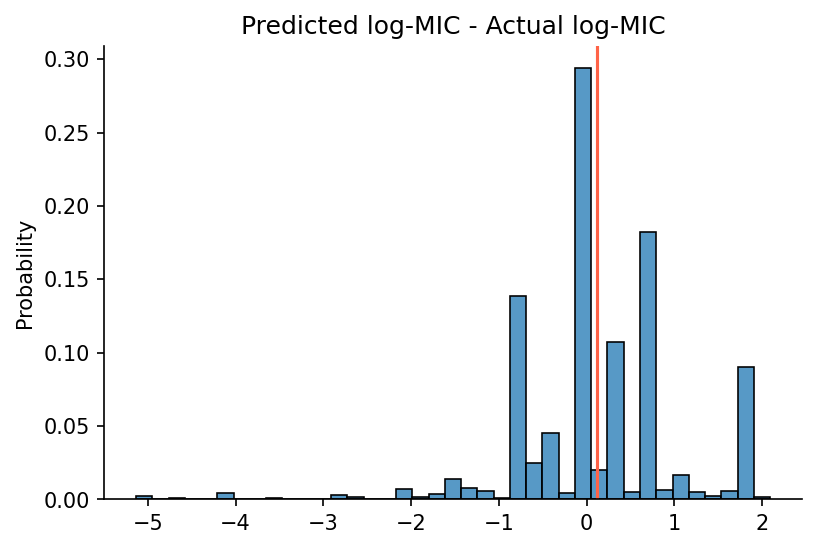

In [53]:
error_dist("20220902_moxi_gyrBA")

-0.006345104482445493 0.8100437303833713


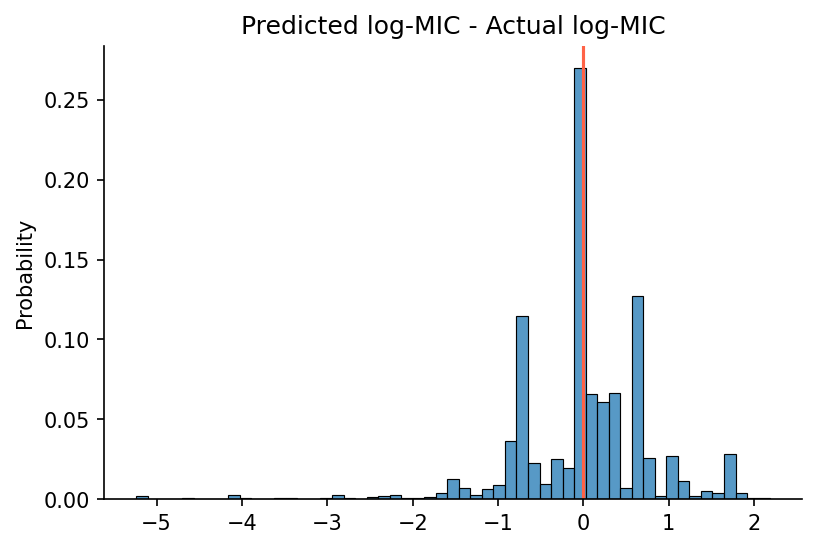

In [54]:
error_dist("20220907_moxi_12Loci")